Обработка файла данных...
Дата эксперимента: 12.11.2025 16:46:52.767
Время от 8 утра: 20812.768 с

Первые 5 строк обработанных данных:
        t       Pg      Pk        Tgaz      Tsvp  T_combined          Rs
0   5.144  770.645  22.992  288.766359  2.393017  288.766359  714.024661
1   6.864  770.664  22.991  288.788161  2.392982  288.788161  714.050443
2   8.583  770.682  22.993  288.808817  2.393051  288.808817  714.009770
3  10.303  770.693  22.996  288.821441  2.393156  288.821441  714.027432
4  12.023  770.710  22.999  288.840953  2.393261  288.840953  714.001863

Статистика данных:
Всего строк: 9410
Диапазон давлений Pg (газ. термометр): 414.3 - 771.8 Торр
Диапазон давлений Pk (криостат): 12.9 - 27.8 Торр
Диапазон температур Tgaz: 79.46 - 290.10 K
Диапазон сопротивлений Rs: 676.057 - 714.380 кОм

График сохранен как: ./test_plot1.pdf


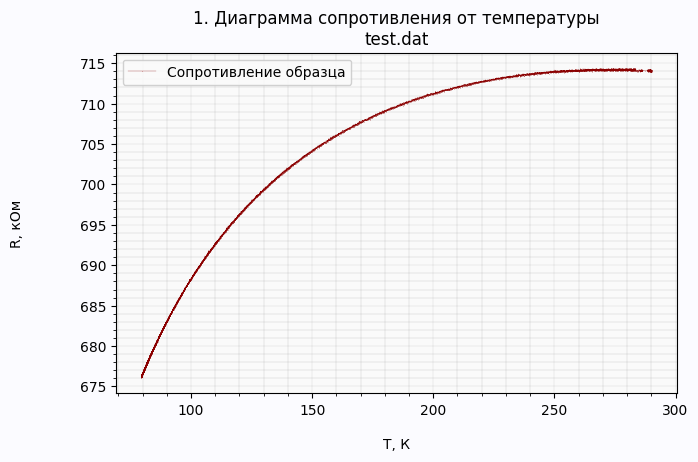

График температуры от времени сохранен как: ./test_plot2.pdf


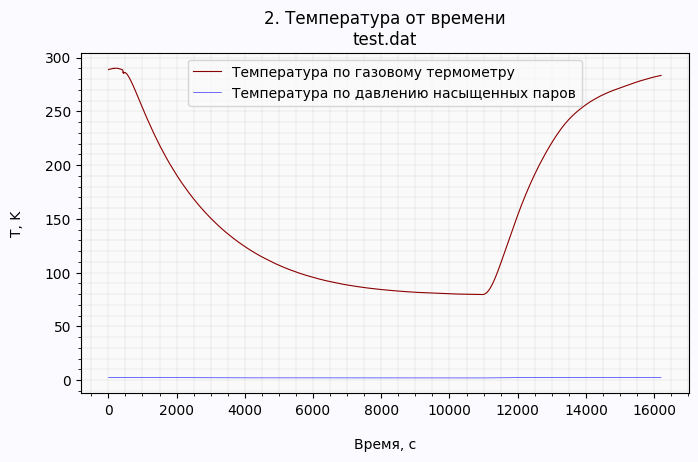

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re

# --- Функция для вычисления температуры по формуле газового термометра
#Зачем-то вызывается каждый раз
def calculate_gas_thermometer_temperature(P, Pg1=776.0, Tg1=295.0, Pg2=406.0, Tg2=77.0):
    """
    Вычисление температуры по формуле газового термометра
    
    Parameters:
    P - давление (Торр)
    Pg1, Tg1 - давление и температура первой калибровочной точки
    Pg2, Tg2 - давление и температура второй калибровочной точки
    """
    # Отношение объемов Vcold/Vroom
    NUg = (Pg1 - Pg2) * Tg2 / (Pg2 * Tg1 - Tg2 * Pg1)
    #print(f"Отношение объемов Vcold/Vroom, NUg = {NUg:.6f}")
    
    # Формула для вычисления температуры
    T = NUg * P * Tg1 / ((NUg + 1) * Pg1 - P)
    return T

# --- Функция для вычисления температуры по давлению насыщенных паров гелия
def he4_svp_temperature(P):
    """
    Вычисление температуры по давлению насыщенных паров гелия-4
    
    Parameters:
    P - давление (Торр)
    """
    # Преобразование Торр в Па (1 Торр = 133.32 Па)
    P_pa = P * 133.32
    
    if P > 1717.64 or P < 0.1:
        return np.nan
    
    if P <= 37.8199:
        x = np.log(P_pa) / 2.9 - 1.93103
        T = (1.392408 + 0.571753 * x + 0.166756 * x**2 + 
             0.669098 * x**3 + 0.026514 * x**4 + 0.001975 * x**5 - 
             0.017976 * x**6 + 0.005409 * x**7 + 0.013259 * x**8)
    else:
        x = np.log(P_pa) / 1.9 - 5.42105
        T = (3.146631 + 1.35765 * x + 0.413923 * x**2 + 
             0.091159 * x**3 + 0.016349 * x**4 + 0.001826 * x**5 - 
             0.004325 * x**6 - 0.004973 * x**7)
    
    return T

# --- Загрузка и обработка данных
def load_and_process_data(filename="./test.dat", RQ=119.35):
    """
    Загрузка данных из файла и вычисление производных величин
    
    Структура файла:
    ## This data file: ...
    ## Programs: ...
    ## Date: 12.11.2025 (Wed), 16:46:52.767
    ## StartTime[t0=24000000 msec]
    ## Time from 8am: 20812.768 s
    ##  t,s   E,V      U0,V        Ux,V        Ug,V     Pg,Torr  Uk,V     Pk,Torr
    """
    # Чтение файла с пропуском комментариев
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Извлечение информации из заголовка
    date_info = None
    time_from_8am = None
    
    for line in lines:
        if line.startswith('## Date:'):
            # Извлечение даты и времени
            date_match = re.search(r'Date: ([\d\.]+) \(.*\), ([\d:\.]+)', line)
            if date_match:
                date_str = date_match.group(1)
                time_str = date_match.group(2)
                date_info = f"{date_str} {time_str}"
        elif 'Time from 8am:' in line:
            time_match = re.search(r'Time from 8am: ([\d\.]+) s', line)
            if time_match:
                time_from_8am = float(time_match.group(1))
    
    print(f"Дата эксперимента: {date_info}")
    print(f"Время от 8 утра: {time_from_8am} с")
    
    # Поиск строки с заголовками столбцов
    data_start_line = 0
    for i, line in enumerate(lines):
        if line.strip().startswith('t,s'):
            data_start_line = i
            break
    
    # Чтение данных (пропускаем комментарии и заголовок)
    data_lines = []
    for i in range(data_start_line, len(lines)):
        line = lines[i].strip()
        if line and not line.startswith('##') and not line.startswith('t,s'):
            # Заменяем E-нотацию для корректного чтения
            line = line.replace('E+', 'e+').replace('E-', 'e-')
            data_lines.append(line)
    
    # Преобразуем строки данных в список значений
    data = []
    for line in data_lines:
        parts = line.split()
        row = []
        for part in parts:
            try:
                # Преобразуем научную нотацию
                if 'e' in part.lower():
                    row.append(float(part))
                else:
                    row.append(float(part))
            except ValueError:
                row.append(np.nan)
        data.append(row)
    
    # Создаем DataFrame
    columns = ['t', 'E', 'U0', 'Ux', 'Ug', 'Pg', 'Uk', 'Pk']
    df = pd.DataFrame(data, columns=columns)
    
    # Вычисление времени от начала измерений
    if time_from_8am is not None:
        # Время в формате HH:MM:SS от 8 утра
        df['time_absolute'] = df['t'] + time_from_8am
        
        # Преобразование в datetime (предполагаем, что эксперимент начался в 8:00)
        start_time = datetime.strptime("08:00:00", "%H:%M:%S")
        df['datetime'] = df['time_absolute'].apply(
            lambda x: start_time + pd.Timedelta(seconds=x)
        )
    
    # Вычисление производных величин
    # Измерительный ток (А)
    df['TQ'] = df['U0'] / RQ / 1000
    
    # Сопротивление образца (кОм)
    df['Rs'] = RQ * df['Ux'] / df['U0']
    
    # Сопротивление образца на минимальном токе
    df['RX_h1'] = np.where(np.abs(df['TQ']) < 3e-6, 
                          df['Ux'] / df['TQ'] / 1000, 
                          np.nan)
    
    # Температура по давлению насыщенных паров (Pk -> Pkap в исходном gnuplot)
    df['Tsvp'] = np.vectorize(he4_svp_temperature)(df['Pk'])
    
    # Температура по формуле газового термометра (Pg -> Pgaz в исходном gnuplot)
    gas_temp_func = np.vectorize(calculate_gas_thermometer_temperature)
    df['Tgaz'] = gas_temp_func(df['Pg'])
    
    # Комбинированная температура
    # Если температура по газовому термометру < 4K, используем SVP
    # Иначе используем SVP если > 2K, иначе газовый термометр
    conditions = [
        (df['Tgaz'] < 4) & (df['Tsvp'].notna()),
        (df['Tsvp'] > 2) & (df['Tsvp'].notna())
    ]
    choices = [
        df['Tsvp'],
        df['Tgaz']
    ]
    df['T_combined'] = np.select(conditions, choices, default=np.nan)
    
    # Проверка первых нескольких строк
    print("\nПервые 5 строк обработанных данных:")
    print(df[['t', 'Pg', 'Pk', 'Tgaz', 'Tsvp', 'T_combined', 'Rs']].head())
    
    return df

# --- Построение графиков
def plot_data(df, filename="test.pdf"):
    """
    Построение графиков аналогичных gnuplot
    """
    # Настройка стиля графика
    plt.rcParams.update({
        'font.size': 10,
        'figure.figsize': (18/2.54, 12/2.54),  # см в дюймы
        'figure.facecolor': '#FBFBFF',
        'axes.facecolor': '#FAFAFA',
        'savefig.facecolor': '#FBFBFF'
    })
    
    # График 1: Диаграмма сопротивления от температуры
    fig1, ax1 = plt.subplots()
    
    # Настройка сетки
    ax1.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax1.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    
    # Включаем минорные деления
    ax1.minorticks_on()
    
    # Заголовок и метки
    base_name = filename.split('/')[-1] if '/' in filename else filename
    ax1.set_title(f"1. Диаграмма сопротивления от температуры\n{base_name}")
    ax1.set_xlabel('T, К', labelpad=15)
    ax1.set_ylabel('R, кОм', labelpad=40)
    
    # Построение графика (фильтруем NaN значения)
    valid_data = df.dropna(subset=['T_combined', 'Rs'])
    ax1.plot(valid_data['T_combined'], valid_data['Rs'], 
            color='darkred', linewidth=0.2, marker='o', 
            markersize=0.3, label='Сопротивление образца', 
            markeredgewidth=0)
    
    ax1.legend(loc='best', frameon=True, framealpha=0.9)
    plt.tight_layout()
    
    # Сохранение в PDF
    output_filename = filename.replace('.dat', '_plot1.pdf')
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\nГрафик сохранен как: {output_filename}")
    plt.show()
    
    # Дополнительный график: температура от времени
    fig2, ax2 = plt.subplots(figsize=(18/2.54, 12/2.54))
    
    ax2.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax2.minorticks_on()
    
    ax2.set_title(f"2. Температура от времени\n{base_name}")
    ax2.set_xlabel('Время, с', labelpad=15)
    ax2.set_ylabel('T, K', labelpad=15)
    
    # Построение температур
    if 'Tgaz' in df.columns:
        ax2.plot(df['t'], df['Tgaz'], color='darkred', linewidth=0.8, 
                label='Температура по газовому термометру')
    if 'Tsvp' in df.columns:
        ax2.plot(df['t'], df['Tsvp'], color='blue', linewidth=0.4, 
                label='Температура по давлению насыщенных паров')
    
    ax2.legend(loc='best')
    plt.tight_layout()
    
    output_filename2 = filename.replace('.dat', '_plot2.pdf')
    plt.savefig(output_filename2, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График температуры от времени сохранен как: {output_filename2}")
    plt.show()
    
    return fig1, fig2

# --- Основная программа
if __name__ == "__main__":
    # Загрузка и обработка данных
    filename = "./test.dat"  # Имя файла из примера
    
    try:
        print("="*60)
        print("Обработка файла данных...")
        print("="*60)
        
        df = load_and_process_data(filename)
        
        print("\n" + "="*60)
        print("Статистика данных:")
        print("="*60)
        print(f"Всего строк: {len(df)}")
        print(f"Диапазон давлений Pg (газ. термометр): {df['Pg'].min():.1f} - {df['Pg'].max():.1f} Торр")
        print(f"Диапазон давлений Pk (криостат): {df['Pk'].min():.1f} - {df['Pk'].max():.1f} Торр")
        print(f"Диапазон температур Tgaz: {df['Tgaz'].min():.2f} - {df['Tgaz'].max():.2f} K")
        print(f"Диапазон сопротивлений Rs: {df['Rs'].min():.3f} - {df['Rs'].max():.3f} кОм")
        
        # Построение графиков
        plot_data(df, filename)
        
    except FileNotFoundError:
        print(f"Ошибка: Файл {filename} не найден.")
        print("Проверьте путь к файлу или создайте тестовый файл данных.")
    except Exception as e:
        print(f"Ошибка при обработке данных: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
df

,t,E,U0,Ux,Ug,Pg,Uk,Pk,time_absolute,datetime,TQ,Rs,RX_h1,Tsvp,Tgaz,T_combined
0,5.144,1.0,0.129222,0.773085,7.7108,770.645,0.23001,22.992,20817.912,1900-01-01 13:46:57.912,0.000001,714.024661,714.024661,2.393017,288.766359,288.766359
1,6.864,1.0,0.129217,0.773083,7.7110,770.664,0.23000,22.991,20819.632,1900-01-01 13:46:59.632,0.000001,714.050443,714.050443,2.392982,288.788161,288.788161
2,8.583,1.0,0.129215,0.773027,7.7111,770.682,0.23003,22.993,20821.351,1900-01-01 13:47:01.351,0.000001,714.009770,714.009770,2.393051,288.808817,288.808817
3,10.303,1.0,0.129222,0.773088,7.7113,770.693,0.23005,22.996,20823.071,1900-01-01 13:47:03.071,0.000001,714.027432,714.027432,2.393156,288.821441,288.821441
4,12.023,1.0,0.129240,0.773168,7.7114,770.710,0.23008,22.999,20824.791,1900-01-01 13:47:04.791,0.000001,714.001863,714.001863,2.393261,288.840953,288.840953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,16196.612,1.0,0.129246,0.773424,7.6628,765.845,0.26915,26.906,37009.380,1900-01-01 18:16:49.380,0.000001,714.205116,714.205116,2.525081,283.328688,283.328688
9406,16198.336,1.0,0.129242,0.773416,7.6629,765.855,0.26915,26.906,37011.104,1900-01-01 18:16:51.104,0.000001,714.219833,714.219833,2.525081,283.339873,283.339873
9407,16200.061,1.0,0.129235,0.773381,7.6630,765.868,0.26915,26.905,37012.829,1900-01-01 18:16:52.829,0.000001,714.226195,714.226195,2.525048,283.354415,283.354415
9408,16201.785,1.0,0.129228,0.773429,7.6631,765.879,0.26913,26.904,37014.553,1900-01-01 18:16:54.553,0.000001,714.309214,714.309214,2.525015,283.366720,283.366720


In [7]:
# Блок 1: Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import warnings
import glob
import os
from pathlib import Path

warnings.filterwarnings('ignore')
print("Библиотеки загружены успешно")


Библиотеки загружены успешно


In [42]:
# Блок 2: Определение функций

def calculate_gas_thermometer_temperature(P, Pg1=776.0, Tg1=295.0, Pg2=406.0, Tg2=77.0):
    """
    Вычисление температуры по формуле газового термометра
    """
    # Отношение объемов Vcold/Vroom
    NUg = (Pg1 - Pg2) * Tg2 / (Pg2 * Tg1 - Tg2 * Pg1)
    
    # Формула для вычисления температуры
    T = NUg * P * Tg1 / ((NUg + 1) * Pg1 - P)
    return T, NUg

def he4_svp_temperature(P):
    """
    Вычисление температуры по давлению насыщенных паров гелия-4
    """
    # Преобразование Торр в Па (1 Торр = 133.32 Па)
    P_pa = P * 133.32
    
    if P > 1717.64 or P < 0.1:
        return np.nan
    
    if P <= 37.8199:
        x = np.log(P_pa) / 2.9 - 1.93103
        T = (1.392408 + 0.571753 * x + 0.166756 * x**2 + 
             0.669098 * x**3 + 0.026514 * x**4 + 0.001975 * x**5 - 
             0.017976 * x**6 + 0.005409 * x**7 + 0.013259 * x**8)
    else:
        x = np.log(P_pa) / 1.9 - 5.42105
        T = (3.146631 + 1.35765 * x + 0.413923 * x**2 + 
             0.091159 * x**3 + 0.016349 * x**4 + 0.001826 * x**5 - 
             0.004325 * x**6 - 0.004973 * x**7)
    
    return T

def read_and_process_file(filename, RQ=119.35):
    """
    Чтение и обработка одного файла данных
    ИСПРАВЛЕНИЕ: В файлах перепутаны Ux и U0
    """
    print(f"Обработка файла: {filename}")
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Поиск строки с заголовками столбцов
    data_start_line = 0
    for i, line in enumerate(lines):
        if line.strip().startswith('t,s'):
            data_start_line = i
            break
    
    # Чтение числовых данных
    data_lines = []
    for i in range(data_start_line, len(lines)):
        line = lines[i].strip()
        if line and not line.startswith('##') and not line.startswith('t,s'):
            line = line.replace('E+', 'e+').replace('E-', 'e-')
            data_lines.append(line)
    
    # Преобразуем строки данных
    data = []
    for line in data_lines:
        parts = line.split()
        row = []
        for part in parts:
            try:
                if 'e' in part.lower():
                    row.append(float(part))
                else:
                    row.append(float(part))
            except ValueError:
                row.append(np.nan)
        data.append(row)
    
    # Создаем DataFrame
    # Согласно заголовку: t,s   E,V      U0,V        Ux,V        Ug,V     Pg,Torr  Uk,V     Pk,Torr
    # НО: В реальности Ux и U0 перепутаны местами в файлах!
    columns = ['t', 'E', 'U0', 'Ux', 'Ug', 'Pg', 'Uk', 'Pk']
    df = pd.DataFrame(data, columns=columns)
    
    # ИСПРАВЛЕНИЕ: В файлах Ux и U0 перепутаны местами
    # Поменяем их местами
    df = df.rename(columns={'U0': 'Ux_temp', 'Ux': 'U0_temp'})
    df = df.rename(columns={'Ux_temp': 'Ux', 'U0_temp': 'U0'})
    
    print(f"  Исправлено: Ux и U0 поменяны местами")
    
    # ФИЛЬТРАЦИЯ: удаляем закаливающие значения (>100 В)
    voltage_columns = ['U0', 'Ux', 'Ug', 'Uk']
    for col in voltage_columns:
        if col in df.columns:
            df = df[df[col].abs() <= 100]
    
    print(f"  Сохранено строк после фильтрации: {len(df)}")
    
    # Вычисление производных величин с ИСПРАВЛЕННЫМИ значениями
    df['TQ'] = df['U0'] / RQ / 1000  # Измерительный ток (А) - теперь с правильным U0!
    df['Rs'] = RQ * df['Ux'] / df['U0']  # Сопротивление образца (кОм) - теперь с правильными Ux и U0!
    
    # Сопротивление на минимальном токе
    df['RX_h1'] = np.where(np.abs(df['TQ']) < 3e-6, 
                          df['Ux'] / df['TQ'] / 1000, 
                          np.nan)
    
    # Температуры
    df['Tsvp'] = df['Pk'].apply(he4_svp_temperature)
    df['Tgaz'] = df['Pg'].apply(lambda x: calculate_gas_thermometer_temperature(x)[0])
    
    # Комбинированная температура
    conditions = [
        (df['Tgaz'] < 4) & (df['Tsvp'].notna()),
        (df['Tsvp'] > 2) & (df['Tsvp'].notna())
    ]
    choices = [
        df['Tsvp'],
        df['Tgaz']
    ]
    df['T_combined'] = np.select(conditions, choices, default=np.nan)
    
    # Дополнительная проверка: убедимся, что вычисления корректны
    if len(df) > 0:
        print(f"  Проверка после исправления:")
        print(f"    Среднее U0: {df['U0'].mean():.3e} В")
        print(f"    Среднее Ux: {df['Ux'].mean():.3e} В")
        print(f"    Средний ток TQ: {df['TQ'].mean():.3e} А")
        print(f"    Среднее сопротивление Rs: {df['Rs'].mean():.3f} кОм")
    
    return df

# Блок 2: Определение функций (обновленная функция load_and_merge_files)

def load_and_merge_files(file_patterns):
    """
    Загрузка и объединение нескольких файлов с сохранением временной последовательности
    """
    all_files = []
    
    for pattern in file_patterns:
        if os.path.isfile(pattern):
            all_files.append(pattern)
        else:
            found_files = glob.glob(pattern, recursive=True)
            all_files.extend(found_files)
    
    all_files = list(set(all_files))
    
    if not all_files:
        print("Файлы не найдены!")
        return None
    
    print(f"Найдено файлов: {len(all_files)}")
    
    # Сначала получим метаданные всех файлов для сортировки по времени
    files_metadata = []
    
    for filename in all_files:
        try:
            # Быстро читаем заголовок для получения времени
            with open(filename, 'r') as f:
                lines = []
                for _ in range(20):  # Читаем первые 20 строк для поиска времени
                    lines.append(f.readline())
                
            # Ищем время в заголовке
            start_time = None
            for line in lines:
                if line.startswith('## Date:'):
                    # Пытаемся извлечь время из строки вида: ## Date: 12.11.2025 (Wed), 16:46:52.767
                    try:
                        time_str = line.split(',')[1].strip()  # "16:46:52.767"
                        # Преобразуем время в секунды
                        h, m, s = map(float, time_str.split(':'))
                        start_time = h * 3600 + m * 60 + s
                        break
                    except:
                        pass
            
            files_metadata.append({
                'filename': filename,
                'basename': os.path.basename(filename),
                'start_time': start_time
            })
            
        except Exception as e:
            print(f"  ✗ Ошибка при чтении метаданных {filename}: {e}")
    
    # Сортируем файлы по времени начала измерений
    if all(m['start_time'] is not None for m in files_metadata):
        # Если у всех файлов есть время, сортируем по нему
        files_metadata.sort(key=lambda x: x['start_time'])
        print("\nФайлы отсортированы по времени начала измерений:")
    else:
        # Иначе сортируем по имени файла (предполагая, что имя содержит время)
        files_metadata.sort(key=lambda x: x['basename'])
        print("\nФайлы отсортированы по имени (предположительно по времени):")
    
    for i, meta in enumerate(files_metadata, 1):
        if meta['start_time']:
            time_str = f"{meta['start_time']//3600:02.0f}:{(meta['start_time']%3600)//60:02.0f}:{meta['start_time']%60:05.2f}"
        else:
            time_str = "время неизвестно"
        print(f"  {i}. {meta['basename']} (начало: {time_str})")
    
    # Теперь читаем и обрабатываем файлы в правильном порядке
    all_dataframes = []
    cumulative_time_offset = 0
    
    for i, meta in enumerate(files_metadata, 1):
        try:
            df = read_and_process_file(meta['filename'])
            
            # Корректируем время для последовательного объединения
            # Сохраняем оригинальное время из файла
            df['original_t'] = df['t'].copy()
            
            # Создаем сквозное время для объединенного датасета
            if i == 1:
                # Для первого файла время начинается с 0
                df['global_time'] = df['t'] - df['t'].min()
                cumulative_time_offset = df['t'].max() - df['t'].min()
            else:
                # Для последующих файлов добавляем смещение
                df['global_time'] = df['t'] - df['t'].min() + cumulative_time_offset + 1.0  # +1 сек между файлами
                cumulative_time_offset = df['global_time'].max()
            
            df['file_index'] = i
            df['file_name'] = meta['basename']
            
            all_dataframes.append(df)
            print(f"  ✓ Файл {i} обработан: {meta['basename']} ({len(df)} строк)")
            
        except Exception as e:
            print(f"  ✗ Ошибка при обработке {meta['filename']}: {e}")
    
    if not all_dataframes:
        print("Нет данных для объединения!")
        return None
    
    # Объединение всех DataFrame
    merged_df = pd.concat(all_dataframes, ignore_index=True)
    
    # Сортируем по глобальному времени
    merged_df = merged_df.sort_values('global_time').reset_index(drop=True)
    
    print(f"\nОбъединенный DataFrame: {len(merged_df)} строк из {len(all_dataframes)} файлов")
    print(f"Общая длительность: {merged_df['global_time'].max() - merged_df['global_time'].min():.1f} с")
    
    # Выводим информацию о файлах в объединенном датасете
    print("\nРаспределение данных по файлам:")
    for i in range(1, len(all_dataframes) + 1):
        file_data = merged_df[merged_df['file_index'] == i]
        if len(file_data) > 0:
            time_start = file_data['global_time'].min()
            time_end = file_data['global_time'].max()
            print(f"  Файл {i}: {time_start:.1f} - {time_end:.1f} с ({len(file_data)} точек)")
    
    return merged_df

print("Функции определены успешно")

Функции определены успешно


In [43]:
# Блок 3: Загрузка нескольких файлов
# Укажите пути к файлам или шаблоны поиска
file_patterns = [
    './1155.dat',           # конкретный файл
    './1542.dat',            # все dat файлы в текущей папке
    './1714.dat',      # все txt файлы в папке data
    # './**/*.dat',        # все dat файлы в текущей и подпапках
]

merged_df = load_and_merge_files(file_patterns)

if merged_df is not None:
    print("\nОбщая статистика:")
    print(f"Общее количество строк: {len(merged_df)}")
    print(f"Количество файлов: {merged_df['file_index'].nunique()}")
    
    # Проверка, что фильтрация сработала
    voltage_stats = {}
    for col in ['U0', 'Ux', 'Ug', 'Uk']:
        if col in merged_df.columns:
            voltage_stats[col] = {
                'min': merged_df[col].min(),
                'max': merged_df[col].max(),
                'mean': merged_df[col].mean()
            }
    
    print("\nДиапазоны напряжений после фильтрации (>100 В отфильтрованы):")
    for col, stats in voltage_stats.items():
        print(f"  {col}: {stats['min']:.3e} - {stats['max']:.3e} В")

Найдено файлов: 3

Файлы отсортированы по времени начала измерений:
  1. 1155.dat (начало: 11:55:53.10)
  2. 1542.dat (начало: 15:42:10.57)
  3. 1714.dat (начало: 17:14:13.42)
Обработка файла: ./1155.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 7886
  Проверка после исправления:
    Среднее U0: 4.614e-01 В
    Среднее Ux: 8.082e-02 В
    Средний ток TQ: 3.866e-06 А
    Среднее сопротивление Rs: 30.186 кОм
  ✓ Файл 1 обработан: 1155.dat (7886 строк)
Обработка файла: ./1542.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 3187
  Проверка после исправления:
    Среднее U0: 1.163e-02 В
    Среднее Ux: 6.353e-03 В
    Средний ток TQ: 9.744e-08 А
    Среднее сопротивление Rs: 73.061 кОм
  ✓ Файл 2 обработан: 1542.dat (3187 строк)
Обработка файла: ./1714.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 7433
  Проверка после исправления:
    Среднее U0: 2.895e-02 В
    Среднее Ux: 8.247e-03 В
    Сред

In [44]:
# Блок 4: Статистика данных
if merged_df is not None:
    print("СТАТИСТИКА ОБЪЕДИНЕННЫХ ДАННЫХ")
    print("="*60)
    
    print(f"Всего строк: {len(merged_df)}")
    print(f"Количество файлов: {merged_df['file_index'].nunique()}")
    print(f"Общая длительность: {merged_df['global_time'].max() - merged_df['global_time'].min():.1f} с")
    
    print(f"\nДиапазон давлений Pg: {merged_df['Pg'].min():.1f} - {merged_df['Pg'].max():.1f} Торр")
    print(f"Диапазон давлений Pk: {merged_df['Pk'].min():.1f} - {merged_df['Pk'].max():.1f} Торр")
    print(f"Диапазон температур Tgaz: {merged_df['Tgaz'].min():.2f} - {merged_df['Tgaz'].max():.2f} K")
    print(f"Диапазон температур Tsvp: {merged_df['Tsvp'].min():.2f} - {merged_df['Tsvp'].max():.2f} K")
    print(f"Диапазон температур T_combined: {merged_df['T_combined'].min():.2f} - {merged_df['T_combined'].max():.2f} K")
    print(f"Диапазон сопротивлений Rs: {merged_df['Rs'].min():.3f} - {merged_df['Rs'].max():.3f} кОм")
    
    print(f"\nСредние значения:")
    print(f"  Pg: {merged_df['Pg'].mean():.1f} Торр")
    print(f"  Pk: {merged_df['Pk'].mean():.1f} Торр")
    print(f"  T_combined: {merged_df['T_combined'].mean():.2f} K")
    print(f"  Rs: {merged_df['Rs'].mean():.3f} кОм")
    
    print("="*60)

СТАТИСТИКА ОБЪЕДИНЕННЫХ ДАННЫХ
Всего строк: 18506
Количество файлов: 3
Общая длительность: 31946.1 с

Диапазон давлений Pg: 2.3 - 771.6 Торр
Диапазон давлений Pk: 0.1 - 923.8 Торр
Диапазон температур Tgaz: 0.28 - 289.89 K
Диапазон температур Tsvp: 0.52 - 4.44 K
Диапазон температур T_combined: 1.42 - 289.89 K
Диапазон сопротивлений Rs: 19.901 - 117.402 кОм

Средние значения:
  Pg: 239.1 Торр
  Pk: 485.5 Торр
  T_combined: 55.94 K
  Rs: 39.735 кОм


После фильтра E != 0: 15875 точек
0.0
1.6
0.0
1.5999999999999996
0.0
1.6000000000000005
0.0
1.5999999999999996
0.0
-1.5999999999999996
0.0
-1.6000000000000005
0.0
-1.5999999999999996
0.0
-1.6
0.0
-1.601
0.0
-1.5990000000000002
0.0
-1.6
0.0
-1.5999999999999996
0.0
-1.6000000000000005
0.0
-1.5999999999999996
0.0
1.5999999999999996
0.0
1.6000000000000005
0.0
1.5999999999999996
0.0
1.6
0.0
2.6
0.0
1.6

Фильтрация завершена:
Всего точек после E != 0: 15875
Стабильные точки (E не меняется > 0.01 В между соседями): 15835
Нестабильные точки: 40
Отфильтровано: 40 точек (0.3%)

График 1 сохранен как: combined_plot1_logT_filtered_E.pdf


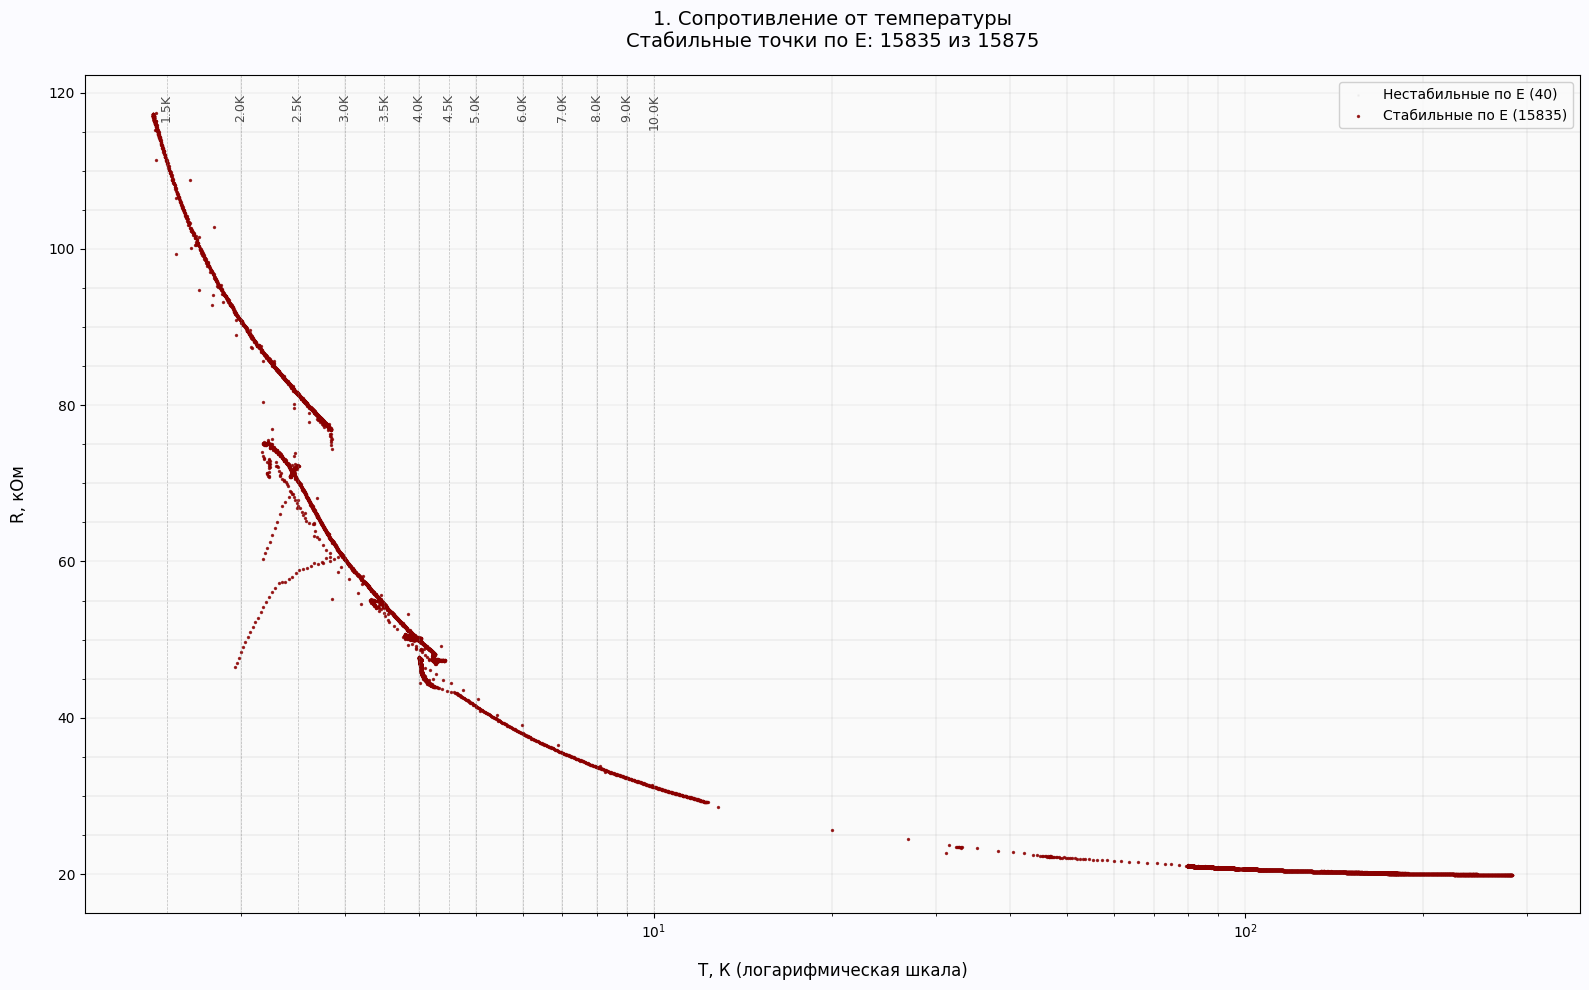


СТАТИСТИКА ФИЛЬТРАЦИИ:

Общая статистика:
  Начальное количество точек: 18506
  После фильтра NaN: 16194
  После фильтра E != 0: 15875
  После фильтра стабильности E: 15835

Статистика стабильных точек:
  Диапазон E: -8.000e+00 - 8.000e+00 В
  Среднее E: 3.585e-01 ± 4.517e-01 В
  Диапазон T: 1.42 - 282.69 K
  Диапазон R: 19.918 - 117.402 кОм
  Количество уникальных значений E: 92
  Среднее изменение E между соседями: 4.051e-03 В
  Макс изменение E между соседями: 2.600e+00 В


In [50]:
# Блок 5: График 1 - Сопротивление от температуры (логарифмическая шкала по T)
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Логарифмический масштаб по оси X
    plt.xscale('log')
    
    # Фильтруем NaN значения
    valid_data = merged_df.dropna(subset=['T_combined', 'Rs']).copy()
    
    # Фильтр 1: E != 0
    valid_data = valid_data[valid_data['E'].abs() > 1e-10].copy()
    print(f"После фильтра E != 0: {len(valid_data)} точек")
    
    # Сортируем по времени для проверки соседних точек
    valid_data = valid_data.sort_values('global_time').reset_index(drop=True)
    
    # Создаем маску для фильтрации по E
    mask_e_stable = np.ones(len(valid_data), dtype=bool)
    
    # Проверяем стабильность напряжения E
    for i in range(1, len(valid_data) - 1):
        # Для E
        e_current = valid_data.loc[i, 'E']
        e_prev = valid_data.loc[i-1, 'E']
        e_next = valid_data.loc[i+1, 'E']
        
        if abs(e_current - e_prev) > 1 or abs(e_current - e_next) > 1:
            print(e_current - e_prev)
            mask_e_stable[i] = False
    
    # Применяем фильтр только по E
    stable_data = valid_data[mask_e_stable].copy()
    unstable_data = valid_data[~mask_e_stable].copy()
    
    print(f"\nФильтрация завершена:")
    print(f"Всего точек после E != 0: {len(valid_data)}")
    print(f"Стабильные точки (E не меняется > 0.01 В между соседями): {len(stable_data)}")
    print(f"Нестабильные точки: {len(unstable_data)}")
    print(f"Отфильтровано: {len(valid_data) - len(stable_data)} точек ({((len(valid_data) - len(stable_data)) / len(valid_data) * 100):.1f}%)")
    
    # Рисуем нестабильные точки (светлым цветом)
    if len(unstable_data) > 0:
        plt.scatter(unstable_data['T_combined'], unstable_data['Rs'], 
                   c='lightgray', s=1, alpha=0.2, label=f'Нестабильные по E ({len(unstable_data)})')
    
    # Рисуем стабильные точки (основной цвет)
    if len(stable_data) > 0:
        plt.scatter(stable_data['T_combined'], stable_data['Rs'], 
                   c='darkred', s=2, alpha=0.8, label=f'Стабильные по E ({len(stable_data)})')
    
        # Скользящее среднее для визуализации тренда
        sorted_stable = stable_data.sort_values('T_combined')
        # if len(sorted_stable) > 10:
        #     window_size = min(50, len(sorted_stable) // 20)
            
        #     plt.plot(sorted_stable['T_combined'], 
        #             sorted_stable['Rs'].rolling(window=window_size, center=True).mean(),
        #             color='blue', linewidth=2.5, 
        #             label=f'Скользящее среднее (окно={window_size})')
    
    plt.title(f"1. Сопротивление от температуры\nСтабильные точки по E: {len(stable_data)} из {len(valid_data)}", 
              fontsize=14, pad=20)
    plt.xlabel('T, К (логарифмическая шкала)', fontsize=12, labelpad=15)
    plt.ylabel('R, кОм', fontsize=12, labelpad=15)
    
    # Характерные температуры
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    
    if len(stable_data) > 0:
        T_min = stable_data['T_combined'].min()
        T_max = stable_data['T_combined'].max()
        
        for temp in characteristic_temps:
            if temp >= T_min and temp <= T_max:
                plt.axvline(x=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
                plt.text(temp, plt.ylim()[1]*0.98, f'{temp}K', 
                        rotation=90, fontsize=9, alpha=0.7, ha='center', va='top')
    
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()
    
    # Сохранение
    output_filename = 'combined_plot1_logT_filtered_E.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\nГрафик 1 сохранен как: {output_filename}")
    plt.show()
    
    # Статистика по фильтрации
    print("\n" + "="*60)
    print("СТАТИСТИКА ФИЛЬТРАЦИИ:")
    print("="*60)
    
    if len(valid_data) > 0:
        print(f"\nОбщая статистика:")
        print(f"  Начальное количество точек: {len(merged_df)}")
        print(f"  После фильтра NaN: {len(merged_df.dropna(subset=['T_combined', 'Rs']))}")
        print(f"  После фильтра E != 0: {len(valid_data)}")
        print(f"  После фильтра стабильности E: {len(stable_data)}")
        
        if len(stable_data) > 0:
            print(f"\nСтатистика стабильных точек:")
            print(f"  Диапазон E: {stable_data['E'].min():.3e} - {stable_data['E'].max():.3e} В")
            print(f"  Среднее E: {stable_data['E'].mean():.3e} ± {stable_data['E'].std():.3e} В")
            print(f"  Диапазон T: {stable_data['T_combined'].min():.2f} - {stable_data['T_combined'].max():.2f} K")
            print(f"  Диапазон R: {stable_data['Rs'].min():.3f} - {stable_data['Rs'].max():.3f} кОм")
            print(f"  Количество уникальных значений E: {stable_data['E'].nunique()}")
            
            # Проверяем, насколько стабильно E в стабильных точках
            e_diffs = []
            for i in range(1, len(stable_data)):
                e_diffs.append(abs(stable_data.iloc[i]['E'] - stable_data.iloc[i-1]['E']))
            
            if e_diffs:
                print(f"  Среднее изменение E между соседями: {np.mean(e_diffs):.3e} В")
                print(f"  Макс изменение E между соседями: {np.max(e_diffs):.3e} В")
        
        print("="*60)

Построение R от времени: 18506 точек из 3 файлов
Общая длительность: 31946.1 с

График R от времени сохранен как: combined_plot_R_vs_time_sequential.pdf


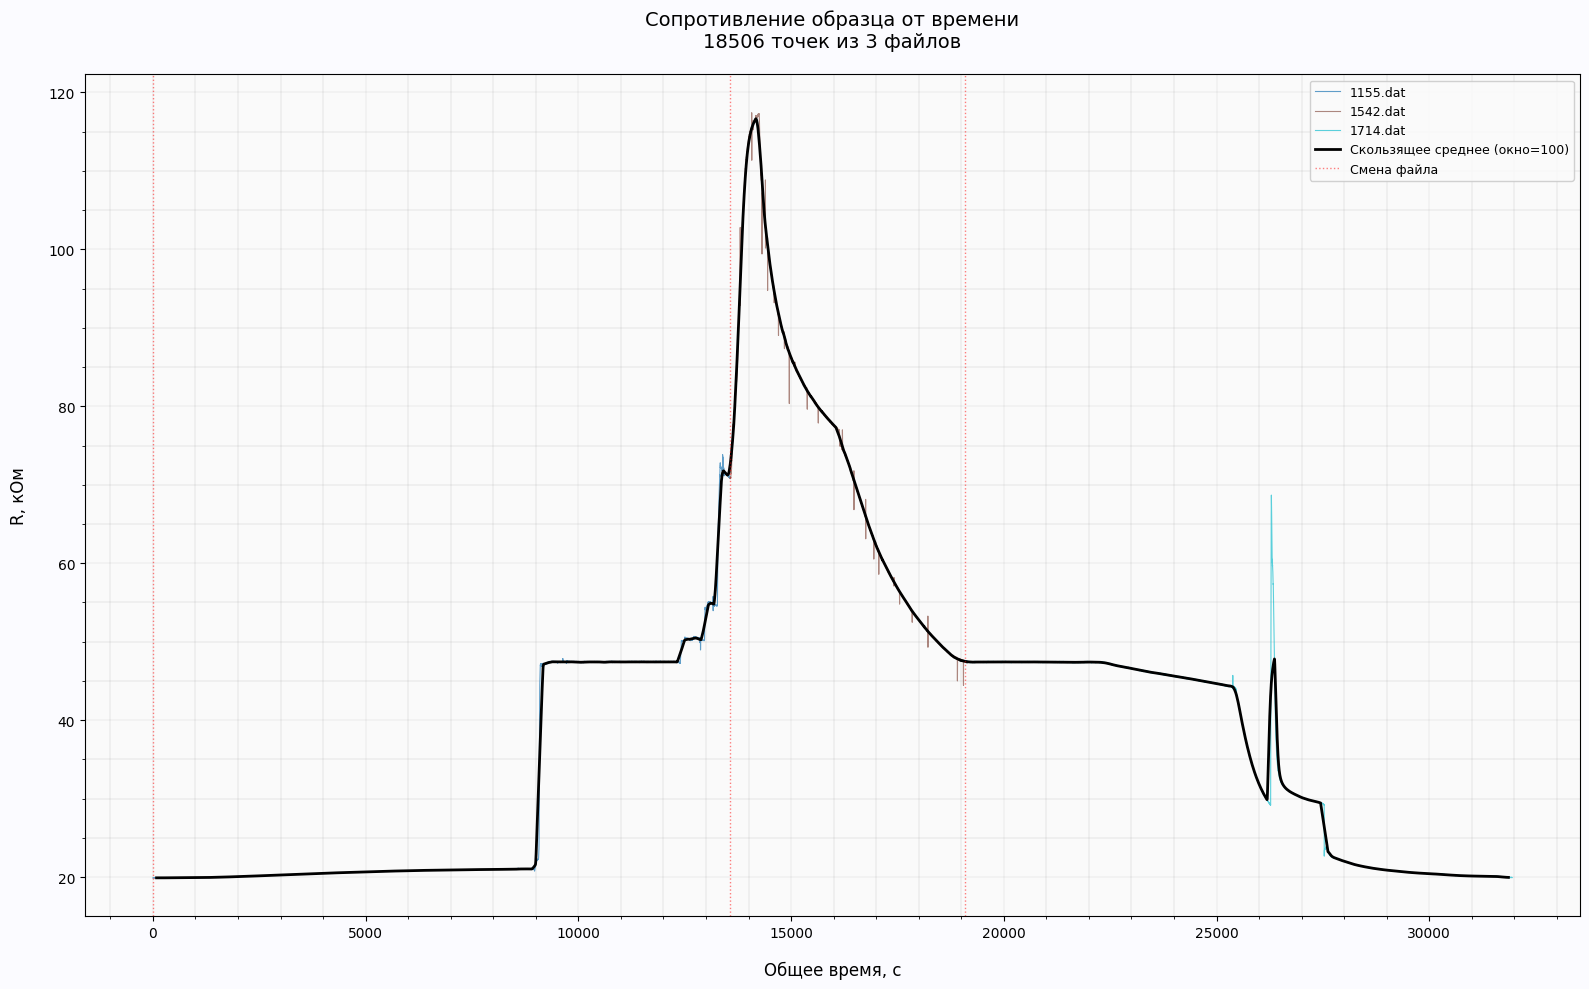


СТАТИСТИКА ПО ФАЙЛАМ:

    Файл  Точек Время начала Время конца Длительность      R мин      R макс  R среднее
1155.dat   7886        0.0 с   13568.1 с    13568.1 с 19.901 кОм  73.832 кОм 30.186 кОм
1542.dat   3187    13569.1 с   19084.0 с     5514.9 с 44.431 кОм 117.402 кОм 73.061 кОм
1714.dat   7433    19085.0 с   31946.1 с    12861.1 с 19.942 кОм  68.681 кОм 35.579 кОм



In [51]:
# Блок X: График - Сопротивление от времени
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Фильтруем NaN значения
    valid_data = merged_df.dropna(subset=['global_time', 'Rs']).copy()
    
    # Сортируем по времени
    valid_data = valid_data.sort_values('global_time')
    
    print(f"Построение R от времени: {len(valid_data)} точек из {merged_df['file_index'].nunique()} файлов")
    print(f"Общая длительность: {valid_data['global_time'].max() - valid_data['global_time'].min():.1f} с")
    
    # Рисуем данные разными цветами для разных файлов
    unique_files = sorted(valid_data['file_index'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_files)))
    
    for file_idx, color in zip(unique_files, colors):
        file_data = valid_data[valid_data['file_index'] == file_idx]
        file_name = file_data['file_name'].iloc[0] if 'file_name' in file_data.columns else f"Файл {file_idx}"
        
        plt.plot(file_data['global_time'], file_data['Rs'], 
                color=color, linewidth=0.8, alpha=0.7, label=file_name)
    
    # Добавляем скользящее среднее по всему датасету
    if len(valid_data) > 10:
        window_size = min(100, len(valid_data) // 50)
        rolling_mean = valid_data['Rs'].rolling(window=window_size, center=True).mean()
        plt.plot(valid_data['global_time'], rolling_mean, 
                color='black', linewidth=2, label=f'Скользящее среднее (окно={window_size})')
    
    plt.title(f"Сопротивление образца от времени\n{len(valid_data)} точек из {len(unique_files)} файлов", 
              fontsize=14, pad=20)
    plt.xlabel('Общее время, с', fontsize=12, labelpad=15)
    plt.ylabel('R, кОм', fontsize=12, labelpad=15)
    
    # Добавляем вертикальные линии при смене файлов
    if len(unique_files) > 1:
        for file_idx in unique_files[1:]:  # Все кроме первого
            file_start_time = valid_data[valid_data['file_index'] == file_idx]['global_time'].min()
            plt.axvline(x=file_start_time, color='red', linestyle=':', 
                       linewidth=1, alpha=0.5)
        
        # Добавляем метку только один раз в легенду
        plt.axvline(x=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Смена файла')
    
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)
    plt.tight_layout()
    
    # Сохранение
    output_filename = 'combined_plot_R_vs_time_sequential.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\nГрафик R от времени сохранен как: {output_filename}")
    plt.show()
    
    # Дополнительный анализ: статистика по каждому файлу
    print("\n" + "="*60)
    print("СТАТИСТИКА ПО ФАЙЛАМ:")
    print("="*60)
    
    file_stats = []
    for file_idx in unique_files:
        file_data = valid_data[valid_data['file_index'] == file_idx]
        if len(file_data) > 0:
            file_name = file_data['file_name'].iloc[0] if 'file_name' in file_data.columns else f"Файл {file_idx}"
            stats = {
                'Файл': file_name,
                'Точек': len(file_data),
                'Время начала': f"{file_data['global_time'].min():.1f} с",
                'Время конца': f"{file_data['global_time'].max():.1f} с",
                'Длительность': f"{file_data['global_time'].max() - file_data['global_time'].min():.1f} с",
                'R мин': f"{file_data['Rs'].min():.3f} кОм",
                'R макс': f"{file_data['Rs'].max():.3f} кОм",
                'R среднее': f"{file_data['Rs'].mean():.3f} кОм",
            }
            file_stats.append(stats)
    
    # Выводим таблицу
    stats_df = pd.DataFrame(file_stats)
    print("\n" + stats_df.to_string(index=False))
    
    print("\n" + "="*60)

График 2 сохранен как: combined_plot2_time_logT.pdf


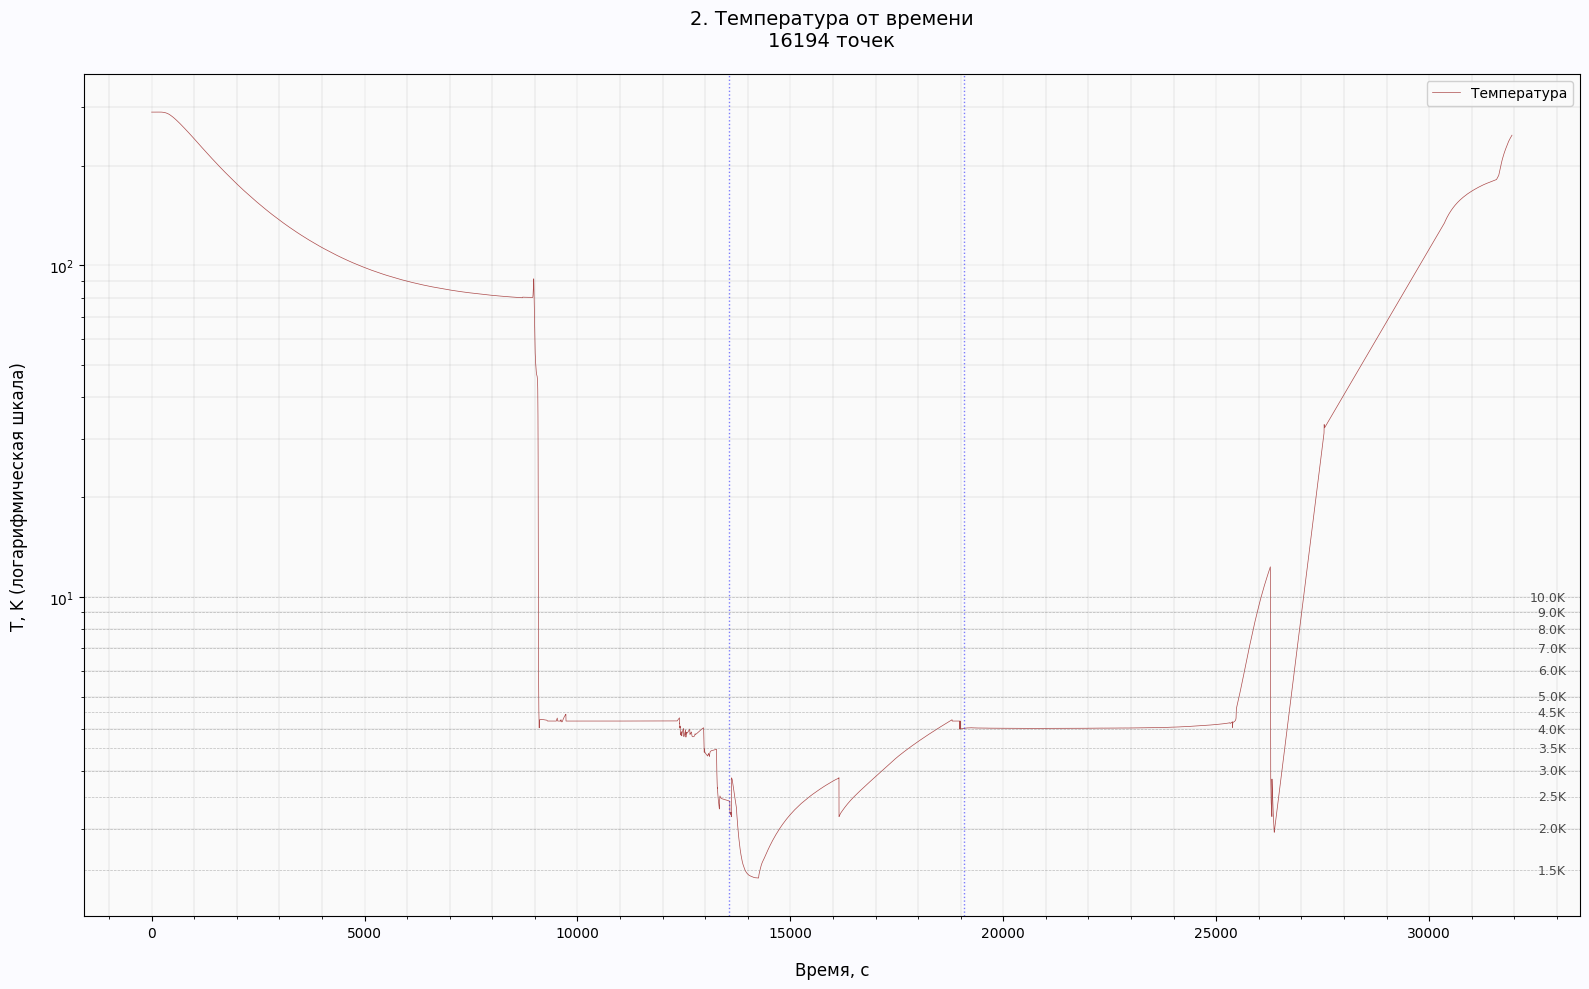

In [47]:
# Блок 6: График 2 - Температура от времени (логарифмическая шкала по Y)
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Логарифмический масштаб по оси Y
    plt.yscale('log')
    
    # Фильтруем NaN значения
    valid_data = merged_df.dropna(subset=['global_time', 'T_combined'])
    
    # Рисуем все данные
    plt.plot(valid_data['global_time'], valid_data['T_combined'], 
            color='darkred', linewidth=0.5, alpha=0.7, label='Температура')
    
    # Добавляем точки изменения файлов (если файлов больше одного)
    if merged_df['file_index'].nunique() > 1:
        file_changes = merged_df.groupby('file_index')['global_time'].first().iloc[1:]
        for change_time in file_changes:
            plt.axvline(x=change_time, color='blue', linestyle=':', 
                       linewidth=1, alpha=0.5)
    
    plt.title(f"2. Температура от времени\n{len(valid_data)} точек", 
              fontsize=14, pad=20)
    plt.xlabel('Время, с', fontsize=12, labelpad=15)
    plt.ylabel('T, K (логарифмическая шкала)', fontsize=12, labelpad=15)
    
    # Характерные температуры
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    T_min = valid_data['T_combined'].min()
    T_max = valid_data['T_combined'].max()
    
    for temp in characteristic_temps:
        if temp >= T_min and temp <= T_max:
            plt.axhline(y=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
            plt.text(plt.xlim()[1]*0.99, temp, f'{temp}K', 
                    fontsize=9, alpha=0.7, ha='right', va='center')
    
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()
    
    output_filename = 'combined_plot2_time_logT.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График 2 сохранен как: {output_filename}")
    plt.show()
    print("="*60)

График 3 сохранен как: combined_plot3_pressures.pdf


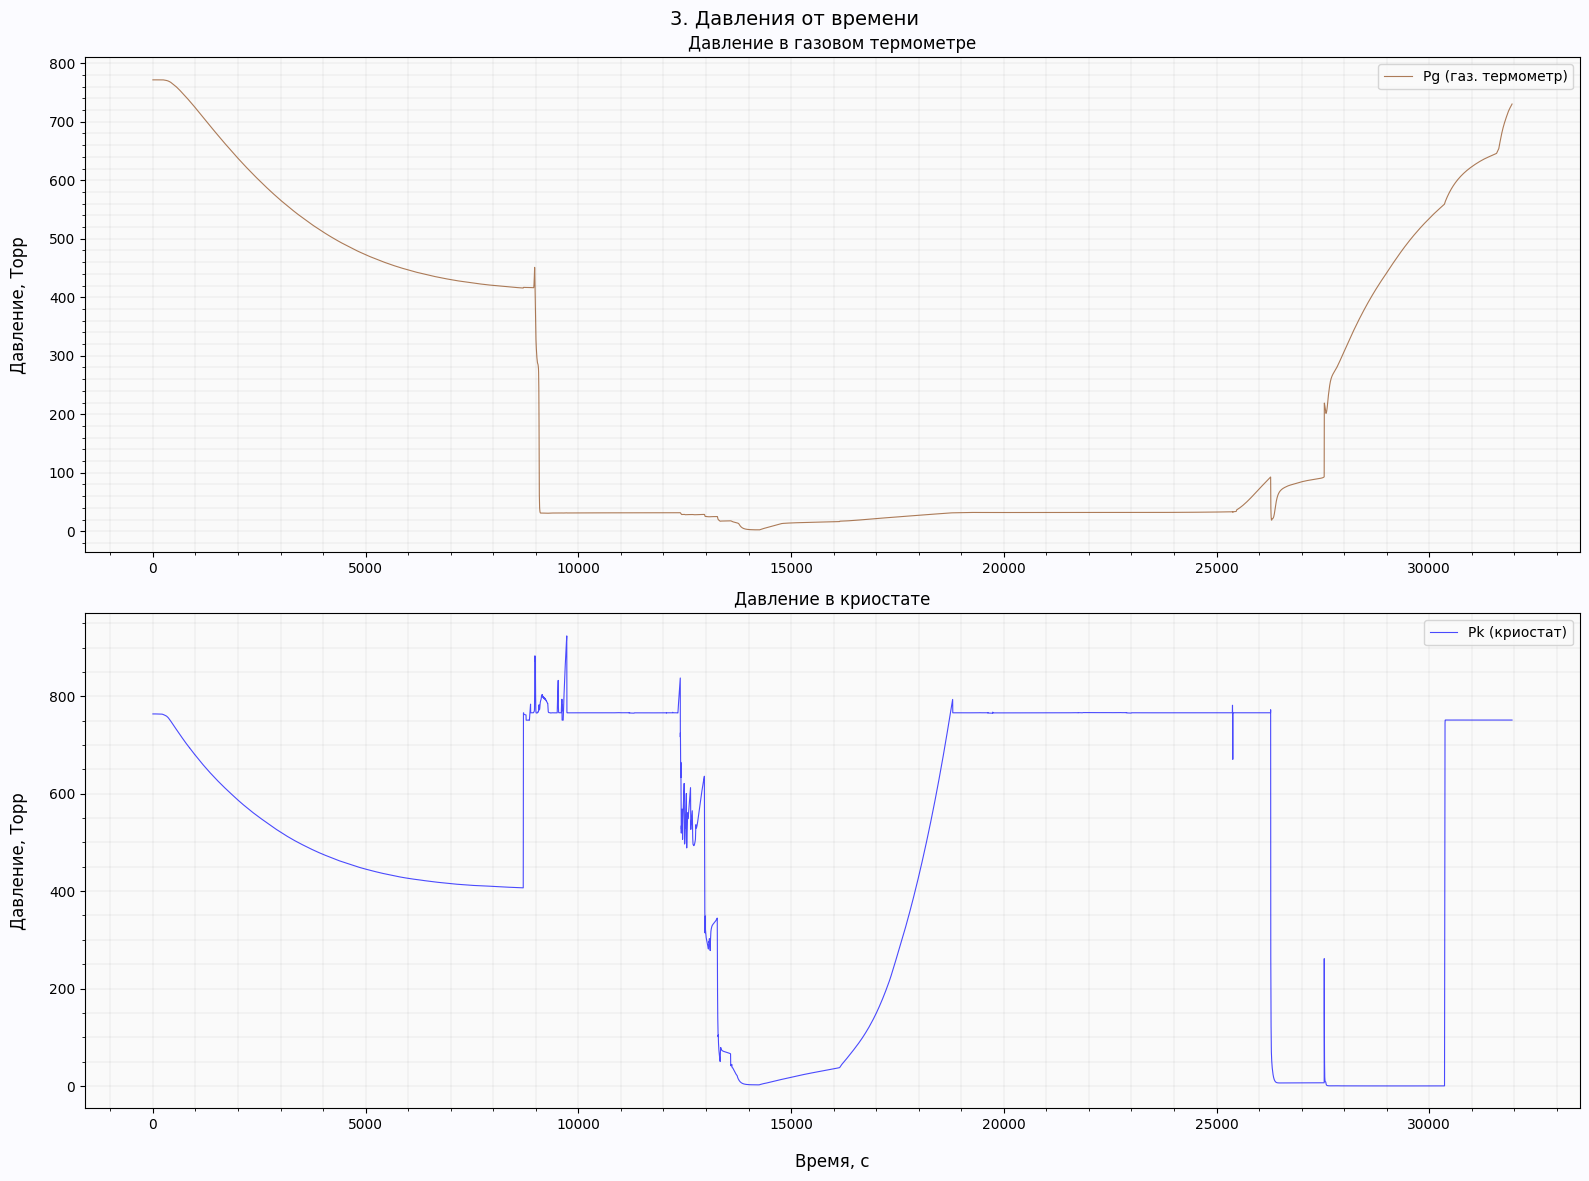

In [48]:
# Блок 7: График 3 - Давления от времени
if merged_df is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    fig.patch.set_facecolor('#FBFBFF')
    
    # Давление в газовом термометре
    ax1.set_facecolor('#FAFAFA')
    ax1.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax1.minorticks_on()
    
    ax1.plot(merged_df['global_time'], merged_df['Pg'], 
            color='saddlebrown', linewidth=0.8, alpha=0.7, label='Pg (газ. термометр)')
    ax1.set_ylabel('Давление, Торр', fontsize=12, labelpad=15)
    ax1.set_title('Давление в газовом термометре', fontsize=12)
    ax1.legend(loc='best')
    
    # Давление в криостате
    ax2.set_facecolor('#FAFAFA')
    ax2.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax2.minorticks_on()
    
    ax2.plot(merged_df['global_time'], merged_df['Pk'], 
            color='blue', linewidth=0.8, alpha=0.7, label='Pk (криостат)')
    ax2.set_xlabel('Время, с', fontsize=12, labelpad=15)
    ax2.set_ylabel('Давление, Торр', fontsize=12, labelpad=15)
    ax2.set_title('Давление в криостате', fontsize=12)
    ax2.legend(loc='best')
    
    plt.suptitle('3. Давления от времени', fontsize=14, y=0.98)
    plt.tight_layout()
    
    output_filename = 'combined_plot3_pressures.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График 3 сохранен как: {output_filename}")
    plt.show()
    print("="*60)

In [49]:
# Блок 9: Сохранение данных и вывод статистики
if merged_df is not None:
    # Сохранение в CSV
    output_csv = 'combined_data.csv'
    merged_df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"Объединенные данные сохранены в: {output_csv}")
    
    # Статистика по напряжениям (проверка фильтрации)
    print("\nПроверка фильтрации напряжений (>100 В):")
    print("-" * 50)
    
    voltage_cols = ['U0', 'Ux', 'Ug', 'Uk']
    for col in voltage_cols:
        if col in merged_df.columns:
            n_outliers = (merged_df[col].abs() > 100).sum()
            total = len(merged_df[col])
            if total > 0:
                percent = n_outliers / total * 100
                print(f"{col}: {n_outliers} значений >100 В ({percent:.2f}% от {total})")
    
    print("\nПервые 5 строк данных:")
    display(merged_df.head())
    
    print("\nОсновные столбцы (первые 10 строк):")
    main_cols = ['global_time', 'Pg', 'Pk', 'T_combined', 'Rs', 'U0', 'Ux']
    display(merged_df[main_cols].head(10))
    
    print("="*60)
    print("ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!")

Объединенные данные сохранены в: combined_data.csv

Проверка фильтрации напряжений (>100 В):
--------------------------------------------------
U0: 0 значений >100 В (0.00% от 18506)
Ux: 0 значений >100 В (0.00% от 18506)
Ug: 0 значений >100 В (0.00% от 18506)
Uk: 0 значений >100 В (0.00% от 18506)

Первые 5 строк данных:


,t,E,Ux,U0,Ug,Pg,Uk,Pk,TQ,Rs,RX_h1,Tsvp,Tgaz,T_combined,original_t,global_time,file_index,file_name
0,5.151,0.0,-0.007069,-0.042383,7.7200,771.571,7.6373,763.661,-3.551119e-07,19.905587,19.905587,4.227193,289.831489,289.831489,5.151,0.000,1,1155.dat
1,6.868,0.0,-0.007074,-0.042393,7.7201,771.575,7.6372,763.655,-3.551982e-07,19.916967,19.916967,4.227185,289.836102,289.836102,6.868,1.717,1,1155.dat
2,8.586,0.0,-0.007072,-0.042404,7.7200,771.571,7.6372,763.657,-3.552928e-07,19.905552,19.905552,4.227188,289.831489,289.831489,8.586,3.435,1,1155.dat
3,10.304,0.0,-0.007075,-0.042400,7.7201,771.579,7.6372,763.660,-3.552602e-07,19.914561,19.914561,4.227192,289.840714,289.840714,10.304,5.153,1,1155.dat
4,12.021,0.0,-0.007074,-0.042379,7.7201,771.577,7.6373,763.662,-3.550825e-07,19.923199,19.923199,4.227195,289.838408,289.838408,12.021,6.870,1,1155.dat



Основные столбцы (первые 10 строк):


,global_time,Pg,Pk,T_combined,Rs,U0,Ux
0,0.000,771.571,763.661,289.831489,19.905587,-0.042383,-0.007069
1,1.717,771.575,763.655,289.836102,19.916967,-0.042393,-0.007074
2,3.435,771.571,763.657,289.831489,19.905552,-0.042404,-0.007072
3,5.153,771.579,763.660,289.840714,19.914561,-0.042400,-0.007075
4,6.870,771.577,763.662,289.838408,19.923199,-0.042379,-0.007074
5,8.587,771.579,763.660,289.840714,19.914723,-0.042395,-0.007074
6,10.305,771.587,763.661,289.849940,19.918149,-0.042393,-0.007075
7,12.023,771.590,763.660,289.853399,19.924916,-0.042393,-0.007077
8,13.740,771.590,763.663,289.853399,19.918032,-0.042385,-0.007074
9,15.460,771.589,763.664,289.852246,19.919031,-0.042394,-0.007075


ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!
